# Bloc 05 - Getaround Analysis 

## 01 - EDA

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Image, display

In [4]:
df = pd.read_excel("../data/get_around_delay_analysis.xlsx")
print(df.head(50))

    rental_id  car_id checkin_type     state  delay_at_checkout_in_minutes  \
0      505000  363965       mobile  canceled                           NaN   
1      507750  269550       mobile     ended                         -81.0   
2      508131  359049      connect     ended                          70.0   
3      508865  299063      connect  canceled                           NaN   
4      511440  313932       mobile     ended                           NaN   
5      511626  398802       mobile     ended                        -203.0   
6      511639  370585      connect     ended                         -15.0   
7      512303  371242       mobile     ended                         -44.0   
8      512475  322502       mobile  canceled                           NaN   
9      513434  256528      connect     ended                          23.0   
10     513743  330658       mobile  canceled                           NaN   
11     514161  366037      connect  canceled                    

In [5]:
df_xlsx = df.copy()

rows, cols = df_xlsx.shape
print("Number of rows :", rows)
print("Number of columns  :", cols)

print()
print("Basics statistics :")
display(df_xlsx.describe(include="all"))

print()
missing_values = df_xlsx.isna().sum() / rows
print("Percentage of missing values:\n", missing_values)

Number of rows : 21310
Number of columns  : 7

Basics statistics :


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
count,21310.000000,21310.000000,21310,21310,16346.000000,1841.000000,1841.000000
unique,NaN,NaN,2,2,NaN,NaN,NaN
top,NaN,NaN,mobile,ended,NaN,NaN,NaN
freq,NaN,NaN,17003,18045,NaN,NaN,NaN
mean,549712.880338,350030.603426,NaN,NaN,59.701517,550127.411733,279.288430
std,13863.446964,58206.249765,NaN,NaN,1002.561635,13184.023111,254.594486
min,504806.000000,159250.000000,NaN,NaN,-22433.000000,505628.000000,0.000000
25%,540613.250000,317639.000000,NaN,NaN,-36.000000,540896.000000,60.000000
50%,550350.000000,368717.000000,NaN,NaN,9.000000,550567.000000,180.000000
75%,560468.500000,394928.000000,NaN,NaN,67.000000,560823.000000,540.000000



Percentage of missing values:
 rental_id                                     0.000000
car_id                                        0.000000
checkin_type                                  0.000000
state                                         0.000000
delay_at_checkout_in_minutes                  0.232942
previous_ended_rental_id                      0.913609
time_delta_with_previous_rental_in_minutes    0.913609
dtype: float64


In [6]:
# suppression des lignes avec la colonne delay_at_checkout_in_minutes vide
df_xlsx.drop(index=df_xlsx[df_xlsx["delay_at_checkout_in_minutes"].isna()].index.to_list(), inplace=True)

# on garde les locations avec le status ended
df_xlsx.drop(index=df_xlsx[df_xlsx["state"] == "canceled"].index.to_list(), inplace=True)

In [7]:
df_ended = df_xlsx.copy()
rows, cols = df_ended.shape

print("Number of rows :", rows)
print("Number of columns  :", cols)

print()
print("Basics statistics :")
display(df_ended.describe(include="all"))

print()
missing_values = df_ended.isna().sum() / rows
print("Percentage of missing values:\n", missing_values)

Number of rows : 16345
Number of columns  : 7

Basics statistics :


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
count,16345.000000,16345.000000,16345,16345,16345.000000,1515.000000,1515.000000
unique,NaN,NaN,2,1,NaN,NaN,NaN
top,NaN,NaN,mobile,ended,NaN,NaN,NaN
freq,NaN,NaN,12943,16345,NaN,NaN,NaN
mean,549859.943652,349015.365800,NaN,NaN,60.773876,549903.475908,276.871287
std,13587.857300,58269.687484,NaN,NaN,993.173222,13385.995247,254.865947
min,504806.000000,159250.000000,NaN,NaN,-22433.000000,505628.000000,0.000000
25%,540868.000000,316920.000000,NaN,NaN,-36.000000,540626.000000,60.000000
50%,550402.000000,367531.000000,NaN,NaN,9.000000,550415.000000,180.000000
75%,560269.000000,393750.000000,NaN,NaN,67.000000,560789.000000,540.000000



Percentage of missing values:
 rental_id                                     0.000000
car_id                                        0.000000
checkin_type                                  0.000000
state                                         0.000000
delay_at_checkout_in_minutes                  0.000000
previous_ended_rental_id                      0.907311
time_delta_with_previous_rental_in_minutes    0.907311
dtype: float64


In [8]:
def show_images(fig, filename):
    fig.write_image(filename)
    display(Image(filename))

### How often are drivers late for the next check-in?

has_delay
True     9404
False    6941
Name: count, dtype: int64


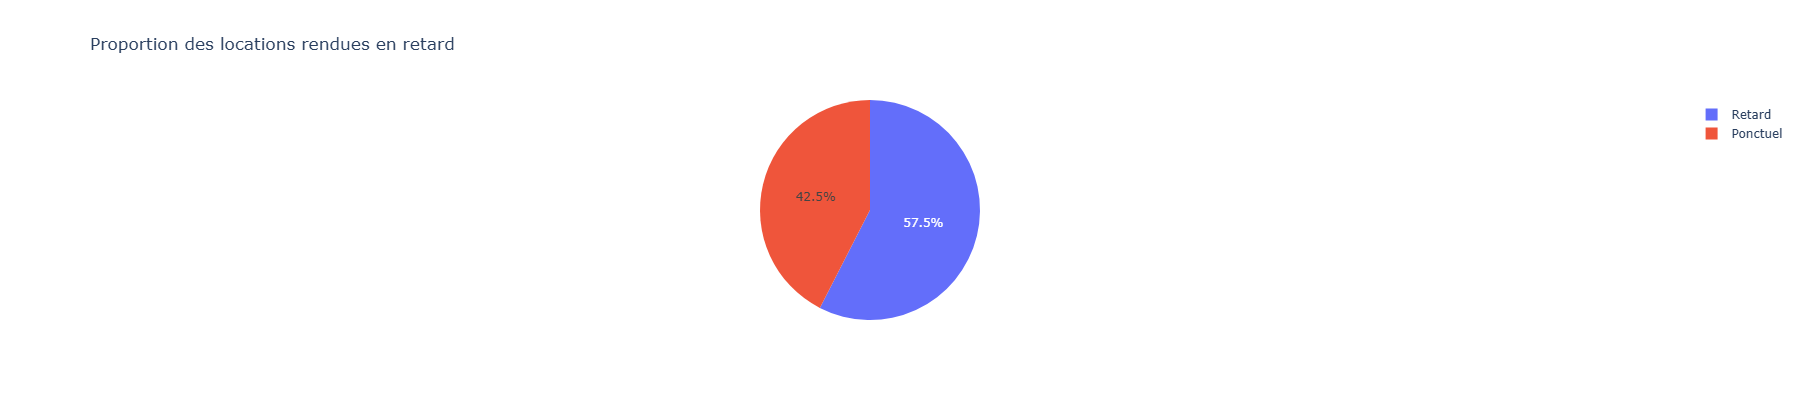

In [9]:
# pourcentage de location arrive en retard
df_ended["has_delay"] = df_ended["delay_at_checkout_in_minutes"] > 0
counts = df_ended["has_delay"].value_counts()
print(counts)

has_delay = px.pie(
    values=counts.values, 
    names=["Retard", "Ponctuel"],
    title="Proportion des locations rendues en retard"
)
has_delay.update_layout(width=1800, height=400)
has_delay.show()

show_images(has_delay, "../images/has_delay.png")

Près de 57% des locations sont rendues avec un retard.

In [10]:
df_ended

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes,has_delay
1,507750,269550,mobile,ended,-81.0,NaN,NaN,False
2,508131,359049,connect,ended,70.0,NaN,NaN,True
5,511626,398802,mobile,ended,-203.0,NaN,NaN,False
6,511639,370585,connect,ended,-15.0,563782.0,570.0,False
7,512303,371242,mobile,ended,-44.0,NaN,NaN,False
...,...,...,...,...,...,...,...,...
21304,573322,376491,connect,ended,-66.0,NaN,NaN,False
21306,573790,341965,mobile,ended,-337.0,NaN,NaN,False
21307,573791,364890,mobile,ended,144.0,NaN,NaN,True
21308,574852,362531,connect,ended,-76.0,NaN,NaN,False


In [11]:
df_with_delay = df_ended[df_ended["has_delay"]].copy()
print(df_with_delay)
print(f"Moyenne : {df_with_delay['delay_at_checkout_in_minutes'].mean()}")
print(f"Médiane : {df_with_delay['delay_at_checkout_in_minutes'].median()}")

       rental_id  car_id checkin_type  state  delay_at_checkout_in_minutes  \
2         508131  359049      connect  ended                          70.0   
9         513434  256528      connect  ended                          23.0   
12        514257  402596       mobile  ended                         214.0   
13        515147  257466       mobile  ended                          15.0   
17        518895  398816       mobile  ended                          66.0   
...          ...     ...          ...    ...                           ...   
21299     571738  406927       mobile  ended                          68.0   
21301     572736  393486       mobile  ended                         180.0   
21303     573305  392752       mobile  ended                          72.0   
21307     573791  364890       mobile  ended                         144.0   
21309     575056  351549      connect  ended                          35.0   

       previous_ended_rental_id  time_delta_with_previous_renta

Grande différence entre moyenne et médiane.  
Certains retards tirent la moyenne vers le haut.  
La fourchette des retards va de -22433 à 71084 minutes.

50% des utilisateurs ont un délai au checkout de 53 minutes ou moins (incluant les avances).

In [13]:
print(df_ended.shape)

print(df_with_delay.shape)

(16345, 8)
(9404, 8)


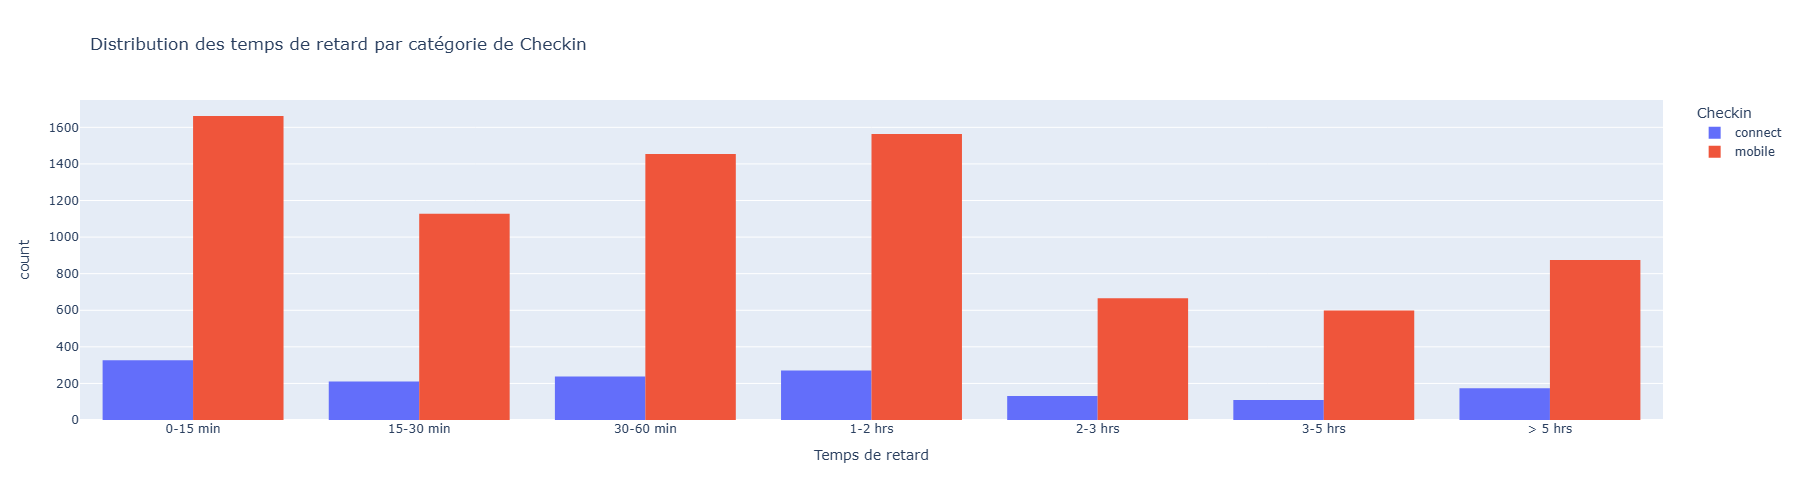

In [14]:
bins = [0, 15, 30, 60, 120, 180, 300, float('inf')]
labels = ["0-15 min",
          "15-30 min",
          "30-60 min", 
          "1-2 hrs",
          "2-3 hrs",
          "3-5 hrs",
          "> 5 hrs"]
df_with_delay["category"] = pd.cut(
    df_with_delay["delay_at_checkout_in_minutes"],
    bins=bins,
    labels=labels,
    right=True
)


delay_cat_fig = px.histogram(x=df_with_delay["category"], 
                   title="Distribution des temps de retard par catégorie de Checkin", 
                   barmode="group", 
                   color=df_with_delay["checkin_type"].sort_values())

delay_cat_fig.update_layout(legend_title_text="Checkin", width=1800, height=500)
delay_cat_fig.update_xaxes(categoryorder='array', categoryarray=labels, title="Temps de retard")
delay_cat_fig.show()

show_images(delay_cat_fig, "../images/delay_cat_fig.png")

Parmi les retards, le checkin de type mobile est systématiquement plus problématique que le connect.

In [15]:
df_time_delta = df_ended[~df_ended["time_delta_with_previous_rental_in_minutes"].isna()][["previous_ended_rental_id", "time_delta_with_previous_rental_in_minutes"]]
df_time_delta.columns = ["curr_rental_id", "time_delta_with_next_rental_in_minutes"]

# pour location courante, on veut savoir quel est le delta connu avec la prochaine location
# par ex: rental_id = 531158, la marge est de 90 (time_delta_with_next_rental_in_minutes)
df_with_next_rental = df_xlsx.merge(df_time_delta, left_on="rental_id", right_on="curr_rental_id", how="left")
df_with_next_rental.drop(columns="curr_rental_id", inplace=True)
df_with_next_rental.to_csv("../data/df_with_next_rental.csv", index=False)
print(df_with_next_rental)


       rental_id  car_id checkin_type  state  delay_at_checkout_in_minutes  \
0         507750  269550       mobile  ended                         -81.0   
1         508131  359049      connect  ended                          70.0   
2         511626  398802       mobile  ended                        -203.0   
3         511639  370585      connect  ended                         -15.0   
4         512303  371242       mobile  ended                         -44.0   
...          ...     ...          ...    ...                           ...   
16340     573322  376491      connect  ended                         -66.0   
16341     573790  341965       mobile  ended                        -337.0   
16342     573791  364890       mobile  ended                         144.0   
16343     574852  362531      connect  ended                         -76.0   
16344     575056  351549      connect  ended                          35.0   

       previous_ended_rental_id  time_delta_with_previous_renta

In [16]:
df_trouble = df_with_next_rental[df_with_next_rental["time_delta_with_next_rental_in_minutes"] < df_with_next_rental["delay_at_checkout_in_minutes"]].copy()
df_trouble["trouble_minutes"] = df_trouble["delay_at_checkout_in_minutes"] - df_trouble["time_delta_with_next_rental_in_minutes"]
print(df_trouble)
print(df_trouble["trouble_minutes"].max())
print(df_trouble["trouble_minutes"].mean())
print(df_trouble["trouble_minutes"].median())


       rental_id  car_id checkin_type  state  delay_at_checkout_in_minutes  \
69        536343  369230       mobile  ended                         780.0   
71        536978  378931       mobile  ended                         271.0   
125       541444  397413       mobile  ended                         901.0   
165       544443  337047       mobile  ended                          56.0   
173       545064  194343      connect  ended                          74.0   
...          ...     ...          ...    ...                           ...   
15617     564990  308181      connect  ended                         133.0   
15638     567682  374360      connect  ended                         172.0   
15808     550671  404424       mobile  ended                         105.0   
15845     545720  367919      connect  ended                           8.0   
16134     561890  412210       mobile  ended                         249.0   

       previous_ended_rental_id  time_delta_with_previous_renta

### How does it impact the next driver?

In [17]:
df_trouble = df_with_delay[(~df_with_delay["time_delta_with_previous_rental_in_minutes"].isna()) & (df_with_delay["time_delta_with_previous_rental_in_minutes"] < df_with_delay["delay_at_checkout_in_minutes"])].copy()
df_trouble["trouble_minutes"] = df_trouble["delay_at_checkout_in_minutes"] - df_trouble["time_delta_with_previous_rental_in_minutes"]
print(df_trouble)
print(f"Max : {df_trouble['trouble_minutes'].max()}")
print(f"Moyenne : {df_trouble['trouble_minutes'].mean()}")
print(f"Médiane : {df_trouble['trouble_minutes'].median()}")

       rental_id  car_id checkin_type  state  delay_at_checkout_in_minutes  \
90        535770  352436       mobile  ended                          74.0   
107       537576  397470       mobile  ended                          18.0   
148       540479  374684       mobile  ended                          12.0   
164       541862  382364       mobile  ended                         125.0   
206       543808  369230       mobile  ended                          75.0   
...          ...     ...          ...    ...                           ...   
20922     561403  412139       mobile  ended                         290.0   
20924     561476  410402       mobile  ended                          11.0   
21054     562649  379751      connect  ended                          72.0   
21163     565721  381470       mobile  ended                          44.0   
21286     569717  377312       mobile  ended                         230.0   

       previous_ended_rental_id  time_delta_with_previous_renta

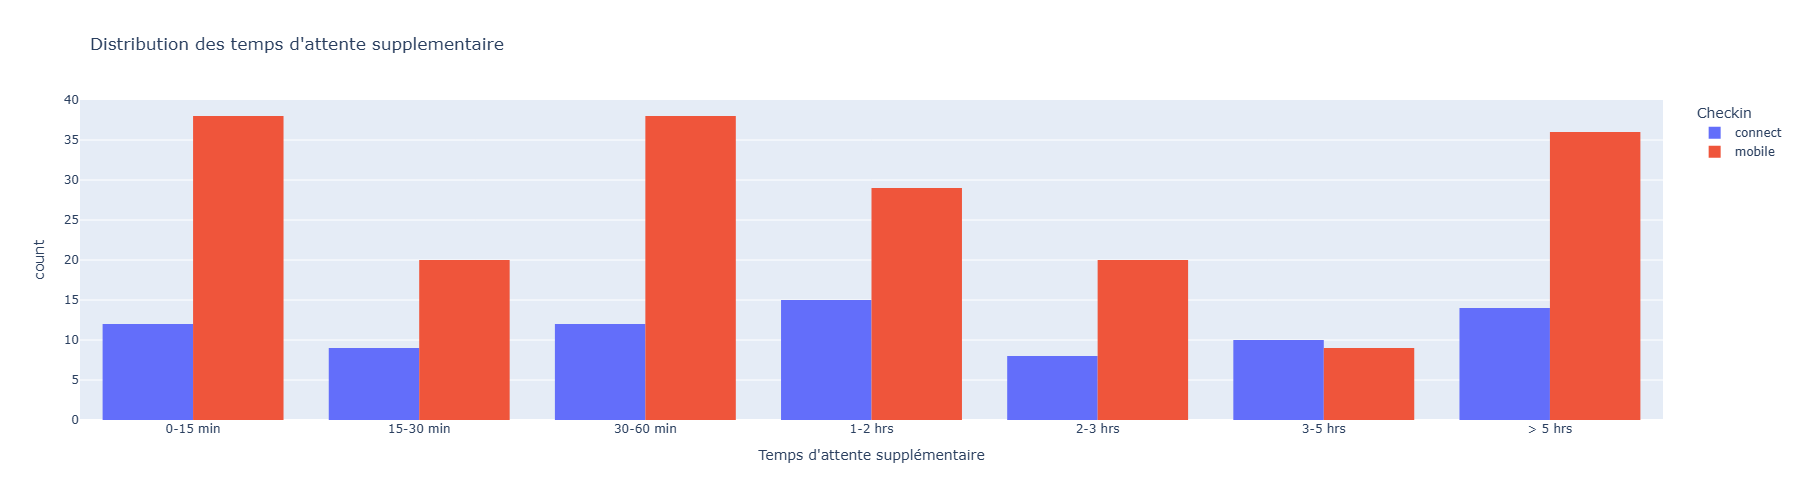

In [18]:
bins = [0, 15, 30, 60, 120, 180, 300, float('inf')]
labels = ["0-15 min",
          "15-30 min",
          "30-60 min", 
          "1-2 hrs",
          "2-3 hrs",
          "3-5 hrs",
          "> 5 hrs"]
df_trouble["trouble_category"] = pd.cut(
    df_trouble["trouble_minutes"],
    bins=bins,
    labels=labels,
    right=True
)

trouble_fig = px.histogram(x=df_trouble["trouble_category"], 
                   title="Distribution des temps d'attente supplementaire", 
                   barmode="group", 
                   color=df_trouble["checkin_type"].sort_values(),)
trouble_fig.update_layout(legend_title_text="Checkin", width=1800, height=500)
trouble_fig.update_xaxes(categoryorder='array', categoryarray=labels, title="Temps d'attente supplémentaire")
trouble_fig.show()

show_images(trouble_fig, "../images/trouble_fig.png")

Ce graphique montre les temps d'attente supplémentaires qu'on dû faire face les conducteurs suite à un retard.  

Par exemple, 29 utilisateurs ont dû attendre entre 15 et 30 minutes pour récupérer leur location.

In [19]:
df_ended

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes,has_delay
1,507750,269550,mobile,ended,-81.0,NaN,NaN,False
2,508131,359049,connect,ended,70.0,NaN,NaN,True
5,511626,398802,mobile,ended,-203.0,NaN,NaN,False
6,511639,370585,connect,ended,-15.0,563782.0,570.0,False
7,512303,371242,mobile,ended,-44.0,NaN,NaN,False
...,...,...,...,...,...,...,...,...
21304,573322,376491,connect,ended,-66.0,NaN,NaN,False
21306,573790,341965,mobile,ended,-337.0,NaN,NaN,False
21307,573791,364890,mobile,ended,144.0,NaN,NaN,True
21308,574852,362531,connect,ended,-76.0,NaN,NaN,False


In [20]:
df_ended.describe()

,rental_id,car_id,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
count,16345.000000,16345.000000,16345.000000,1515.000000,1515.000000
mean,549859.943652,349015.365800,60.773876,549903.475908,276.871287
std,13587.857300,58269.687484,993.173222,13385.995247,254.865947
min,504806.000000,159250.000000,-22433.000000,505628.000000,0.000000
25%,540868.000000,316920.000000,-36.000000,540626.000000,60.000000
50%,550402.000000,367531.000000,9.000000,550415.000000,180.000000
75%,560269.000000,393750.000000,67.000000,560789.000000,540.000000
max,576401.000000,417675.000000,71084.000000,575053.000000,720.000000
